In [16]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

df = pd.read_csv('cleaned_housesales_data.csv')

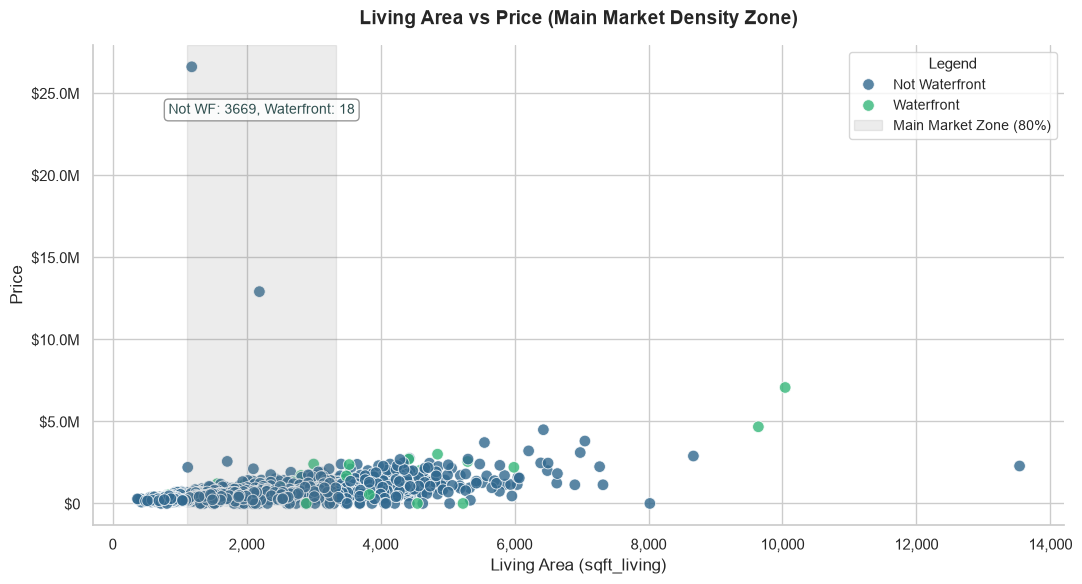

In [18]:
sns.set_theme(style='whitegrid')
plt.figure(figsize=(11, 6))

df['waterfront_label'] = df['waterfront'].map(
    {0: 'Not Waterfront', 1: 'Waterfront'}
)

x_min = df['sqft_living'].quantile(0.10)
x_max = df['sqft_living'].quantile(0.90)

zone_df = df[(df['sqft_living'] >= x_min) & (df['sqft_living'] <= x_max)]
count_not_wf = (zone_df['waterfront'] == 0).sum()
count_wf = (zone_df['waterfront'] == 1).sum()

ax = sns.scatterplot(
    data=df,
    x='sqft_living',
    y='price',  
    hue='waterfront_label',
    palette='viridis',
    alpha=0.8,
    s=70,
)

# highlighting stuff
plt.axvspan(
    x_min,
    x_max,
    color='gray',
    alpha=0.15,
    ymin=0,
    ymax=1,
    label='Main Market Zone (80%)',
)

zone_text = f'Not WF: {count_not_wf}, Waterfront: {count_wf}'
plt.text(
    (x_min + x_max) / 2,
    plt.ylim()[1] * 0.85,
    zone_text,
    horizontalalignment='center',
    fontsize=10,
    color='darkslategray',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8, edgecolor='gray'),
)


ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{int(x):,}'))

# y axis formatting
ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(
        lambda x, pos: (
            f'${x*1e-6:.1f}M'
            if x >= 1e6
            else f'${x*1e-3:.0f}K' if x >= 1e3 else f'${x:.0f}'
        )
    )
)

plt.title(
    'Living Area vs Price (Main Market Density Zone)',
    fontsize=14,
    fontweight='bold',
    pad=15,
)
plt.xlabel('Living Area (sqft_living)', fontsize=12)
plt.ylabel('Price', fontsize=12)

plt.legend(title='Legend', title_fontsize='11', fontsize=10)

sns.despine(top=True, right=True)
plt.tight_layout()
plt.show()